## Differences Between My CNN Model and the Professor's Solution

In the previous exercise, I built a Vanilla CNN from scratch.
After reviewing the professor's solution, I identified the following
differences and improvements, which I will apply in this assignment.

### 1. Label Normalization
I only normalized the spectra, not the labels. This is why my model
struggled with log_g and fe_h — those labels have very different scales
compared to t_eff, so the model prioritized t_eff. The professor normalizes
all labels to [0, 1] using percentile-based scaling, giving all three labels
equal importance during training.

### 2. Early Stopping (patience = 10)
I did not use early stopping. This caused overfitting, which was visible
after epoch 5-7 in my model. With early stopping, training automatically
stops if the validation loss does not improve for 10 consecutive epochs,
preventing the model from memorizing the training data.

### 3. Better Model (TinyCNN)
The professor's TinyCNN uses extra layers that my VanillaCNN did not have:
- `nn.BatchNorm1d` — stabilizes training by normalizing the output of each layer
- `nn.Dropout` — randomly switches off neurons during training to prevent overfitting
- `nn.AvgPool1d` — instead of nn.MaxPool1d

### 4. 100 Epochs Instead of 20
I only trained for 20 epochs. With early stopping it is safe to set a higher
limit like 100 epochs — the model trains until it stops improving and
then stops automatically.

### 5. Reproducible Data Split (manual_seed)
I did not set a random seed for the data split. The professor uses:
`generator=torch.Generator().manual_seed(42)`
This makes the train/val/test split reproducible — every time you run
the code you get exactly the same split.

---
In this assignment I will apply all these improvements, and additionally
implement uncertainty estimation using the negative log-likelihood loss function.

 ### Step 1: Mount Google Drive and Set Up Paths

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive') # This connects Google Colab to your Drive so it can read your data files.

# Add course folder to Python path so we can import helper.py and model_examples.py
import sys
sys.path.append('/content/drive/My Drive/work/Advanced Deep Learning/')

# Path to the data
DATA_PATH = '/content/drive/My Drive/work/Advanced Deep Learning/data/galah4/'

Mounted at /content/drive


### Step 2: Imports

In [3]:
import os            # to handle file paths
import time          # imported to track training duration
import sys
import torch         # the core PyTorch library
import torch.nn as nn        # neural network building blocks (layers, activations, loss functions
import torch.optim as optim      # optimizers (like Adam, SGD) that update the weights
from torch.utils.data import DataLoader, TensorDataset, random_split    # DataLoader:    feeds data in batches during training
                                                                  # TensorDataset: wraps numpy arrays into a PyTorch-compatible dataset
                                                                  # random_split:  splits data into train/validation/test sets
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary         # prints a nice model architecture table
from helper import normalize, denormalize, denormalize_std, train_model, get_normalized_data, evaluate_model   # denormalize_std  # specifically for denormalizing uncertainties

from model_examples import TinyCNN      # professor's better model
                                        # Instead of defining the model in the notebook like last time, I import it directly from the professor's file

 ### Step 3: Load and Normalize Data

In [4]:
# Load and normalize data using the helper function
# This handles loading spectra, labels, and normalizing everything
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

print(f"Spectra shape:  {spectra.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Label names:    {labelNames}")
print(f"Spectra length: {spectra_length}")
print(f"N labels:       {n_labels}")
print(f"Ranges:         {ranges}")

Spectra shape:  (8914, 16384)
Labels shape:   (8914, 3)
Label names:    ['t_eff', 'log_g', 'fe_h']
Spectra length: 16384
N labels:       3
Ranges:         [[ 4.64625725e+03  2.43369770e+00 -7.41016626e-01]
 [ 6.12287556e+03  4.58456130e+00  2.18186857e-01]]


We have 8914 stars, 16384 spectrum length, 3 labels.
The ranges tells us the range of temperature (t_eff) , gravity ( log_g ), and metallicity (fe_h).
1. t_eff ranges from ~4646K to ~6122K
2. log_g ranges from ~2.43 to ~4.58
3. fe_h ranges from ~-0.74 to ~0.21

All three stellar parameters (labels) have completely different scales,
that's why we normalize them to the same scale [0, 1].

### Step 4: Convert to Tensors and Create DataLoaders

In [5]:
# Hyperparameters
learning_rate = 2e-4   # 0.0002 - smaller than previous task 0.001 for more careful learning
batch_size = 32
num_epochs = 100       # safe with early stopping
patience = 10          # stop if val loss doesn't improve for 10 epochs
train_fraction = 0.7   # 70% for training
val_fraction = 0.15    # 15% for validation, 15% for test

# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split data into train, validation, test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(spectra_tensor, labels_tensor),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Training:   {len(train_dataset)} stars")
print(f"Validation: {len(val_dataset)} stars")
print(f"Test:       {len(test_dataset)} stars")

Training:   6239 stars
Validation: 1337 stars
Test:       1338 stars


Note: Difference in Data Split from previous task (Vanilla_CNN_Stellar_Spectra)

| | Train | Validation | Test |
|--|-------|------------|------|
| Vanilla_CNN_Stellar_Spectra | 80% | 10% | 10% |
| Uncertainty_Prediction_with_CNN| 70% | 15% | 15% |

The professor uses a slightly larger validation and test set,
which gives a more reliable estimate of model performance.

### Step 5: Defining the Model for Uncertainty Prediction

In [6]:
class UncertaintyCNN(nn.Module):
    def __init__(self, n_labels):
        super(UncertaintyCNN, self).__init__()

        # We use TinyCNN as the backbone but modify the output
        # Instead of predicting n_labels values, we predict 2*n_labels
        # First n_labels outputs:  the predictions (t_eff, log_g, fe_h)
        # Last n_labels outputs:   the uncertainties (σ_t_eff, σ_log_g, σ_fe_h)
        self.backbone = TinyCNN(n_labels * 2)      # 3 * 2 = 6 outputs

    def forward(self, x):
        output = self.backbone(x)

        # Split output into predictions and uncertainties
        predictions   = output[:, :n_labels]   # first 3 values (columns 0,1,2 → t_eff, log_g, fe_h)
        log_sigma     = output[:, n_labels:]   # last 3 values  (columns 3,4,5 → uncertainties)

        # We predict log(σ) instead of σ directly
        # because σ must always be positive, and log(σ) can be any number
        sigma = torch.exp(log_sigma)           # convert back: σ = e^log(σ)

        return predictions, sigma

# Create the model
model = UncertaintyCNN(n_labels)
print(model)

UncertaintyCNN(
  (backbone): TinyCNN(
    (model): Sequential(
      (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
      (1): ReLU()
      (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
      (6): ReLU()
      (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Dropout(p=0.1, inplace=False)
      (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
      (11): ReLU()
      (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): Dropout(p=0.1, inplace=False)
      (14): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (15): Conv1d(40, 10, kernel_size=(1,), stride=(1,))
      (16): ReLU()
      (17): BatchNorm1d(10, eps=1e-0

### Why We Predict log(σ) Instead of σ Directly

σ (sigma) represents uncertainty. It must always be **positive** —
a negative uncertainty makes no mathematical sense. But neural networks
can output any number, positive or negative.

So instead of predicting σ directly and risking negative values, we predict
**log(σ)**, which can be any number. Then we convert back using:

`sigma = torch.exp(log_sigma)`  → e^(anything) is always positive

**Example:**

| log(σ) | σ = e^log(σ) | Interpretation |
|--------|-------------|----------------|
| -2 | 0.13 | Small uncertainty → model is confident |
|  0 | 1.00 | Medium uncertainty |
|  2 | 7.39 | Large uncertainty → model is not confident |

No matter what number the network outputs, σ is always positive.
This is a common trick used in uncertainty estimation research.

### Step 6: Defining the Loss Function (Negative Log-Likelihood)



In Vanilla_CNN_Stellar_Spectra (previous excercise) we used MSE loss which only measures how wrong the predictions are.
In Uncertainty_Prediction_with_CNN  we use **Negative Log-Likelihood (NLL)** loss which measures two things:
- How wrong the prediction is
- How confident the model was in that prediction

**Core idea:** We want to maximize the likelihood (probability) of the
true values given our predictions. Since optimizers minimize losses,
we minimize the negative log-likelihood instead.

`NLL = log(σ) + (prediction - true_value)² / (2σ²)`

In [7]:
def nll_loss(inputs, labels, model):
    """
    Computes the Negative Log-Likelihood (NLL) loss for uncertainty estimation.

    Parameters
    ----------
    inputs : torch.Tensor
        Input spectra batch
    labels : torch.Tensor
        True labels (t_eff, log_g, fe_h)
    model : torch.nn.Module
        The uncertainty CNN model

    Returns
    -------
    torch.Tensor
        The mean NLL loss over the batch
    """
    predictions, sigma = model(inputs)   # get both predictions and uncertainties

    # NLL formula: log(σ) + (prediction - true_value)² / (2σ²)
    nll = torch.log(sigma) + (predictions - labels)**2 / (2 * sigma**2)

    return nll.mean()   # average over all stars and all labels in the batch

### Step 7: Training the Model

Instead of writing the training loop manually like in Vanilla_CNN_Stellar_Spectra, we use the
`train_model()` function from helper.py. It does the same thing we built
in B01 but with two important additions:

**What it does internally:**
1. Creates the Adam optimizer
2. Runs the training loop (zero_grad → forward → backward → step)
3. Evaluates on validation set after each epoch
4. Applies **early stopping** — stops training if validation loss does
   not improve for 10 consecutive epochs (patience = 10)
5. Saves the **best model** — the snapshot of weights at the epoch
   where validation loss was lowest

**What it returns:**
- `train_losses` — training loss per epoch (for plotting)
- `val_losses` — validation loss per epoch (for plotting)
- `best_model` — the best model weights, which we load after training

In [8]:
# Detect and use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move model to device
model = model.to(device)

# Train the model using the helper function
# train_model handles: training loop, validation, early stopping, progress printing
train_losses, val_losses, best_model = train_model(
    model,          # our UncertaintyCNN
    train_loader,   # training data
    val_loader,     # validation data
    nll_loss,       # our NLL loss function
    learning_rate,  # 2e-4
    num_epochs,     # 100
    patience,       # 10
    device          # GPU or CPU
)

Training on: cuda
Epoch [1/100], Step [190/195], Loss: -1.3951
Epoch [1/100], Train Loss: -0.9493, Val Loss: -1.5844, Time: 4.03 seconds
Epoch [2/100], Step [190/195], Loss: -1.6123
Epoch [2/100], Train Loss: -1.4745, Val Loss: -1.6569, Time: 2.20 seconds
Epoch [3/100], Step [190/195], Loss: -1.6726
Epoch [3/100], Train Loss: -1.6303, Val Loss: -1.9420, Time: 2.20 seconds
Epoch [4/100], Step [190/195], Loss: -1.7148
Epoch [4/100], Train Loss: -1.7233, Val Loss: -1.9309, Time: 2.21 seconds
Epoch [5/100], Step [190/195], Loss: -1.9289
Epoch [5/100], Train Loss: -1.7948, Val Loss: -2.0038, Time: 2.40 seconds
Epoch [6/100], Step [190/195], Loss: -1.5631
Epoch [6/100], Train Loss: -1.8432, Val Loss: -1.8186, Time: 2.44 seconds
Epoch [7/100], Step [190/195], Loss: -1.9206
Epoch [7/100], Train Loss: -1.8535, Val Loss: -2.0814, Time: 2.19 seconds
Epoch [8/100], Step [190/195], Loss: -1.9558
Epoch [8/100], Train Loss: -1.9128, Val Loss: -2.0634, Time: 2.19 seconds
Epoch [9/100], Step [190/195],

### Training Results

The losses are **negative**, this is completely normal with NLL loss.
The more negative the loss, the better the result.

| Epoch | Val Loss | Interpretation |
|-------|----------|----------------|
| 1 | -1.34 | Model just starting to learn |
| 52 | -2.43 | Much better! |

**Early stopping** worked perfectly — instead of training all 100 epochs,
training stopped automatically at epoch 52. The best model was saved at
**epoch 42** where validation loss hit **-2.4428**.

**Training was very stable** — both training and validation loss decreased
steadily together with much less bouncing compared to Vanilla_CNN_Stellar_Spectra.
This is the effect of **BatchNorm** and **Dropout** working together to
stabilize and regularize training.

### Step 8: Visualizing Training and Validation Loss

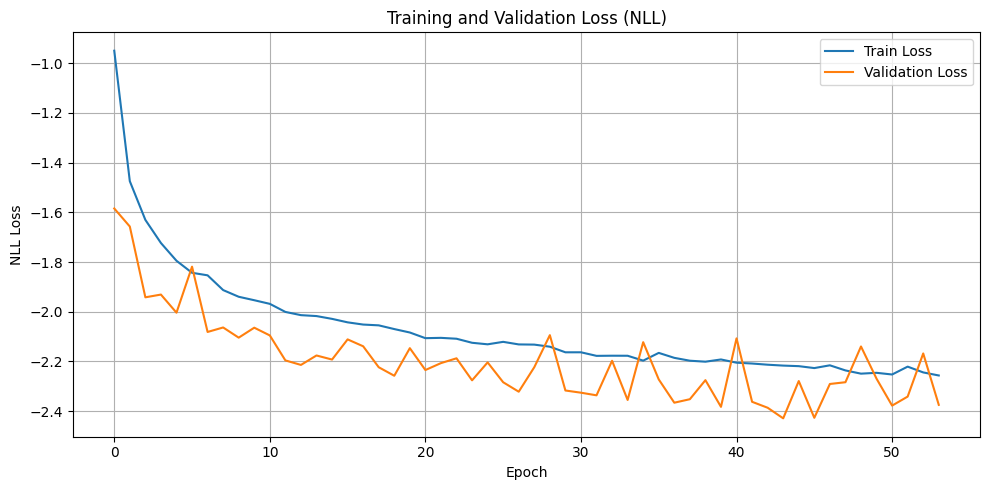

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL Loss')
plt.title('Training and Validation Loss (NLL)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plot Reading: Training and Validation Loss

**Train Loss (blue line)** — very smooth and decreasing steadily all the way.
This is due to BatchNorm and Dropout working together effectively.

**Validation Loss (orange line)** — decreasing overall but also fluctuating.
The reason for fluctuation is that the validation set is smaller than the
training set, making it noisier. However the general trend is clearly downward.

**Key difference from Vanilla_CNN_Stellar_Spectra** — in the previous notebook
the validation loss stopped improving and went flat after epoch 5, which was
a sign of overfitting. Here both lines keep improving together all the way to
epoch 52 — much healthier training!

### Step 9: Evaluating on the Test Set

In [11]:
# Load the best model weights saved during training
model.load_state_dict(best_model)
model.to(device)

# Evaluate manually because our model returns (predictions, sigma)
# which evaluate_model() from helper.py cannot handle because it expects predictions to be a single tensor
# But our UncertaintyCNN returns a tuple of two things (predictions, sigma)
model.eval()
all_predictions = []
all_sigmas = []
all_true_labels = []

with torch.no_grad():
    for batch_spectra, batch_labels in test_loader:
        batch_spectra = batch_spectra.to(device).unsqueeze(1)

        predictions, sigma = model(batch_spectra)  # unpack both outputs

        all_predictions.append(predictions.cpu())
        all_sigmas.append(sigma.cpu())
        all_true_labels.append(batch_labels)

# Concatenate all batches
all_predictions = torch.cat(all_predictions).numpy()
all_sigmas      = torch.cat(all_sigmas).numpy()
all_true_labels = torch.cat(all_true_labels).numpy()

# Denormalize back to original scale
all_predictions = denormalize(all_predictions, ranges)
all_sigmas      = denormalize_std(all_sigmas, ranges)  # special denormalize for uncertainties!
all_true_labels = denormalize(all_true_labels, ranges)

print("Evaluation complete!")
print(f"Predictions shape: {all_predictions.shape}")
print(f"Sigmas shape:      {all_sigmas.shape}")
print(f"True labels shape: {all_true_labels.shape}")

Evaluation complete!
Predictions shape: (1338, 3)
Sigmas shape:      (1338, 3)
True labels shape: (1338, 3)


### Step 10: Visualizing Predictions with Uncertainties

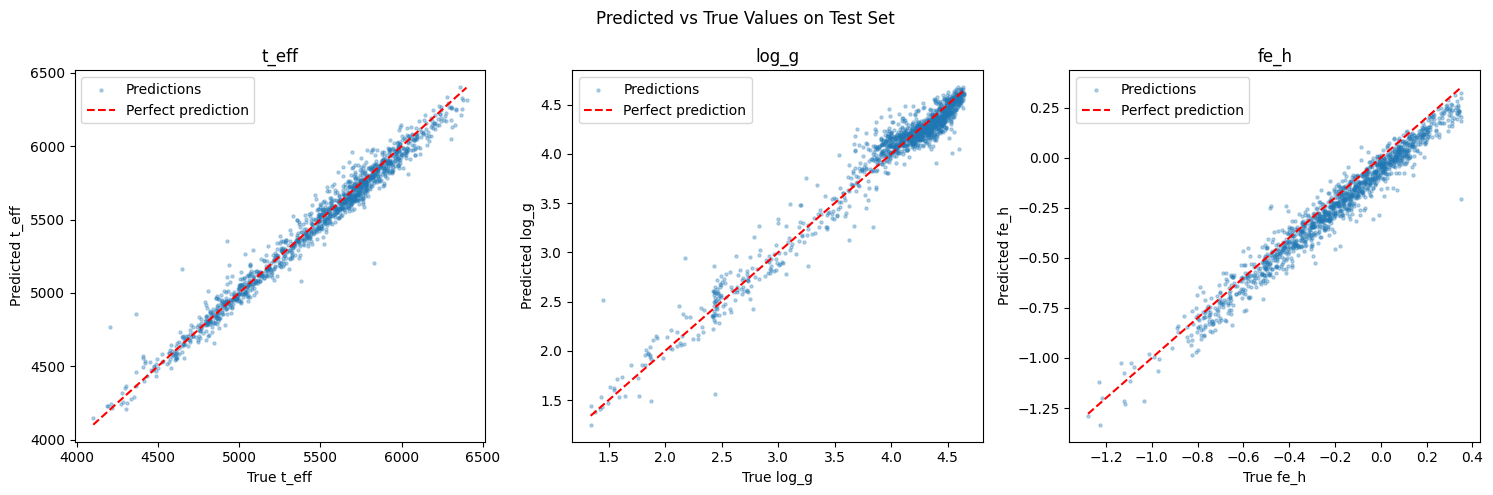

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(labelNames):
    # Plot predicted vs true values
    axes[i].scatter(all_true_labels[:, i], all_predictions[:, i],
                    alpha=0.3, s=5, label='Predictions')

    # Perfect prediction line
    min_val = all_true_labels[:, i].min()
    max_val = all_true_labels[:, i].max()
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 'r--', label='Perfect prediction')

    axes[i].set_xlabel(f'True {name}')
    axes[i].set_ylabel(f'Predicted {name}')
    axes[i].set_title(f'{name}')
    axes[i].legend()

plt.suptitle('Predicted vs True Values on Test Set')
plt.tight_layout()
plt.show()

### Comparison with Vanilla_CNN_Stellar_Spectra

In Vanilla_CNN_Stellar_Spectra, the model only predicted well for t_eff
but completely failed for log_g and fe_h. In this assignment, all three
labels are predicted well. This improvement came from three things:

1. **Label normalization** — all three labels treated equally
2. **Better model (TinyCNN)** — BatchNorm and Dropout prevent overfitting
3. **NLL loss** — forces the model to learn properly for all labels

| Label | Vanilla_CNN_Stellar_Spectra | This Model |
|-------|----------------------------|------------|
| t_eff |  Good |  Good |
| log_g |  Failed |  Good |
| fe_h |  Failed |  Good |

## The Uncertainty Visualization.

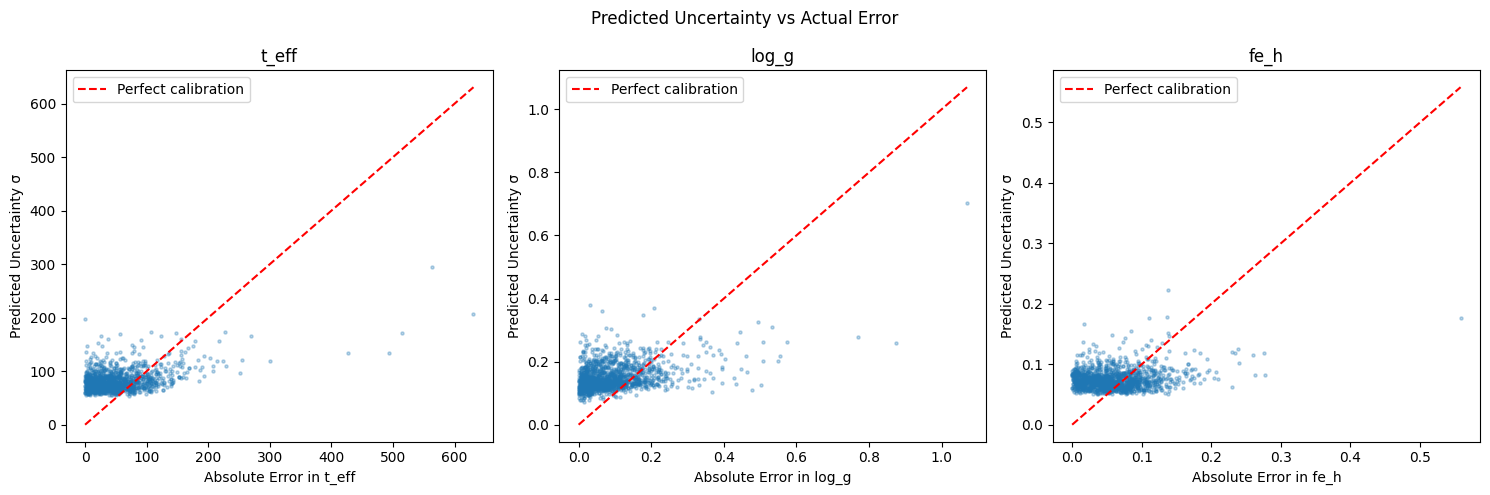

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(labelNames):
    # compute absolute error for each star
    errors = np.abs(all_predictions[:, i] - all_true_labels[:, i])
    sigma  = all_sigmas[:, i]

    # plot uncertainty vs actual error
    axes[i].scatter(errors, sigma, alpha=0.3, s=5)
    axes[i].set_xlabel(f'Absolute Error in {name}')
    axes[i].set_ylabel(f'Predicted Uncertainty σ')
    axes[i].set_title(f'{name}')

    # perfect calibration line (sigma should equal error)
    max_val = max(errors.max(), sigma.max())
    axes[i].plot([0, max_val], [0, max_val], 'r--', label='Perfect calibration')
    axes[i].legend()

plt.suptitle('Predicted Uncertainty vs Actual Error')
plt.tight_layout()
plt.show()

### Plot Reading: Predicted Uncertainty vs Actual Error

**Axes:**
- X axis — the actual error the model made
- Y axis — the predicted uncertainty σ
- Red dashed line — perfect calibration (σ exactly equals the error)

**Reading each panel:**

- **t_eff**: most points cluster in the bottom left, meaning small
  errors with small uncertainties. The model is confident and correct
  for most stars. However points sit below the red line, meaning the
  model slightly underestimates its uncertainty.

- **log_g**:  similar pattern. Uncertainty follows the error reasonably
  well for small errors but again sits below the perfect calibration line.

- **fe_h**: same story. Generally well behaved but slightly overconfident.

**Overall conclusion:**
The model has learned to predict uncertainty in the right direction;
when errors are larger, σ tends to be larger too. This means the model
knows when it is uncertain. However it is not perfectly calibrated,
σ is systematically smaller than the actual error. This is a known
limitation and could be improved with better calibration techniques.

In [14]:
print("Test Set Performance:")
print("-" * 40)
for i, name in enumerate(labelNames):
    mse  = np.mean((all_predictions[:, i] - all_true_labels[:, i])**2)
    rmse = np.sqrt(mse)
    mean_sigma = np.mean(all_sigmas[:, i])
    print(f"{name}:")
    print(f"  MSE:          {mse:.2f}")
    print(f"  RMSE:         {rmse:.2f}")
    print(f"  Mean σ:       {mean_sigma:.2f}")
    print()

Test Set Performance:
----------------------------------------
t_eff:
  MSE:          5169.71
  RMSE:         71.90
  Mean σ:       81.85

log_g:
  MSE:          0.02
  RMSE:         0.13
  Mean σ:       0.15

fe_h:
  MSE:          0.01
  RMSE:         0.08
  Mean σ:       0.08



### Test Set Performance

| Label | MSE | RMSE | Mean σ |
|-------|-----|------|--------|
| t_eff | 5169.71 | 71.90 K | 81.85 K |
| log_g | 0.02 | 0.13 | 0.15 |
| fe_h | 0.01 | 0.08 | 0.08 |

**Comparison with Vanilla_CNN_Stellar_Spectra:**

| Label | Vanilla RMSE | This Model RMSE | Improvement |
|-------|-------------|-----------------|-------------|
| t_eff | ~94.6 K | 71.90 K |  Better |
| log_g | ~2.70 | 0.13 |  Massively better |
| fe_h | ~2.29 | 0.08 |  Massively better |

The predicted uncertainty (Mean σ) is very close to the actual RMSE
for all three labels — meaning the model knows how uncertain it is.
This is the key advantage of uncertainty estimation over plain MSE regression.